In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('/Customer-Churn-Records - Copy.csv')


In [18]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [20]:
df.shape

(10000, 18)

In [21]:
print(df.isnull().sum())

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


/tmp/ipykernel_20554/1812163812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, ax=axes[0], palette='viridis')


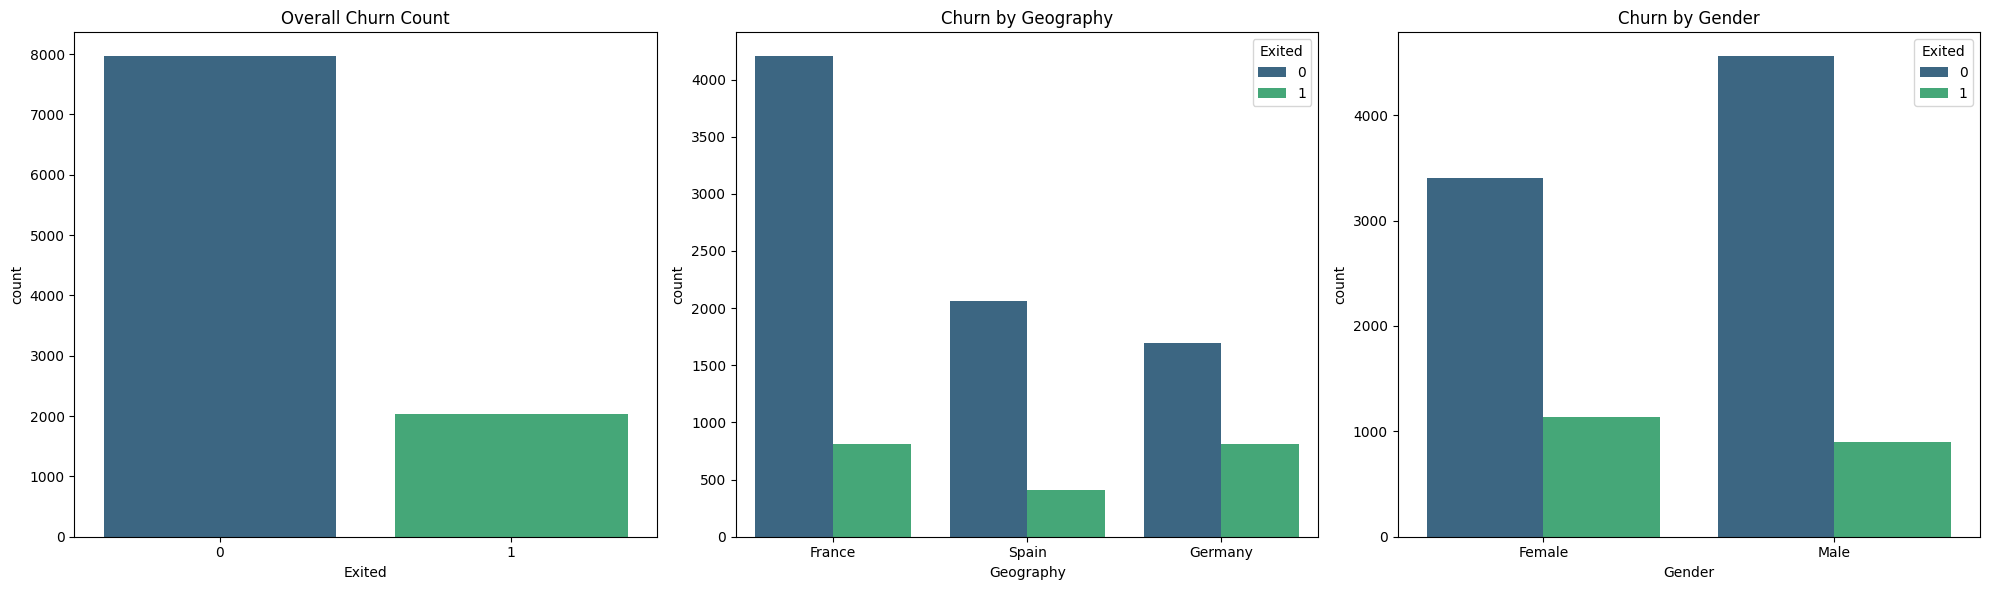

In [22]:
# Churn, Geo, Gender Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Overall Churn
sns.countplot(x='Exited', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Overall Churn Count')

# Geography-wise
sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Churn by Geography')

# Gender-wise
sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Churn by Gender')

plt.tight_layout()
plt.show()

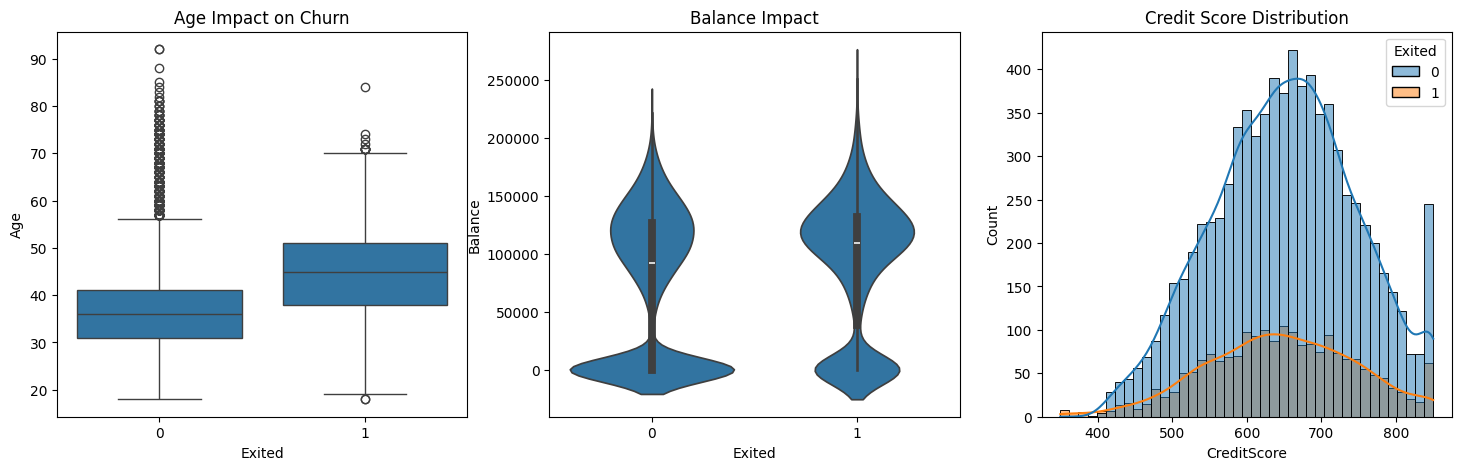

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Churn
sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0])
axes[0].set_title('Age Impact on Churn')

# Balance vs Churn
sns.violinplot(x='Exited', y='Balance', data=df, ax=axes[1])
axes[1].set_title('Balance Impact')

# Credit Score
sns.histplot(x='CreditScore', hue='Exited', data=df, kde=True, ax=axes[2])
axes[2].set_title('Credit Score Distribution')
plt.show()

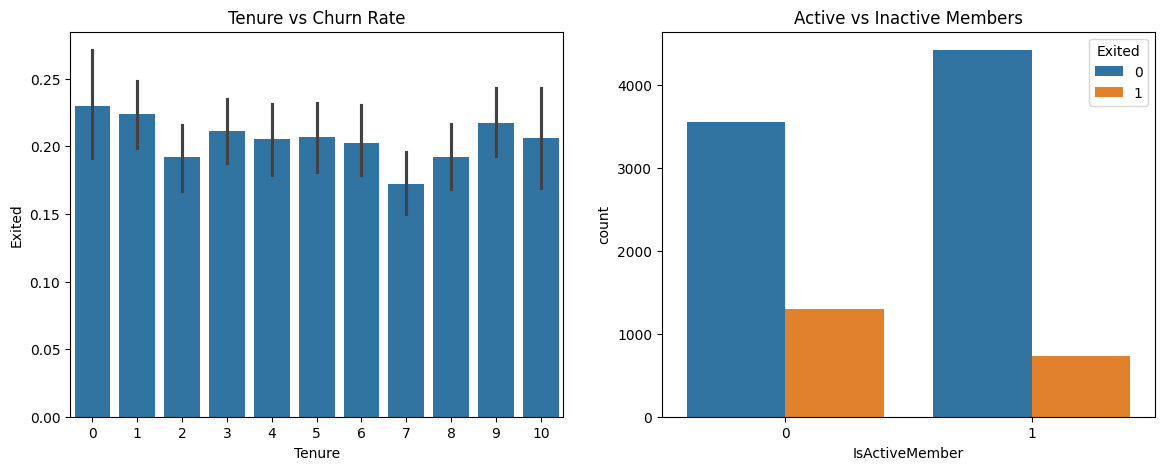

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure Impact
sns.barplot(x='Tenure', y='Exited', data=df, ax=axes[0])
axes[0].set_title('Tenure vs Churn Rate')

# Active Member
sns.countplot(x='IsActiveMember', hue='Exited', data=df, ax=axes[1])
axes[1].set_title('Active vs Inactive Members')
plt.show()

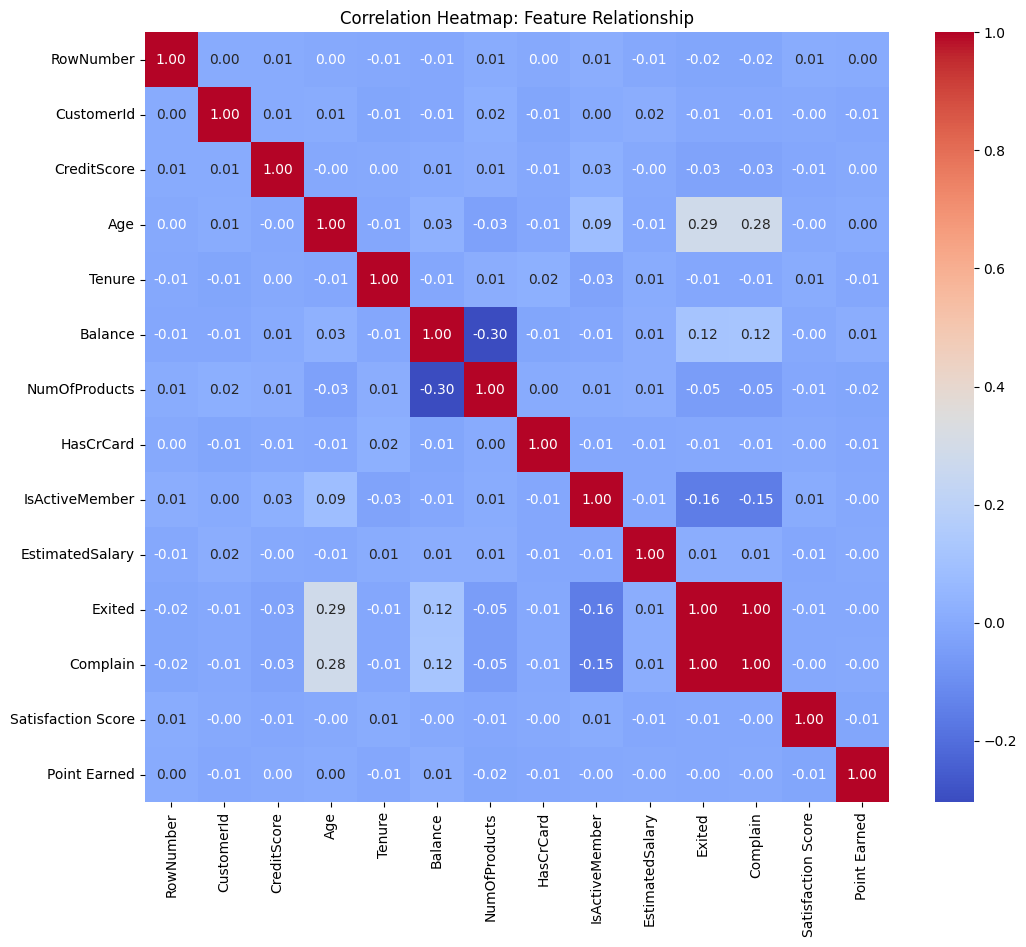

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Feature Relationship')
plt.show()

In [26]:
# High-Risk Criteria: Age > 45, Inactive, Balance > 50k
high_risk_segment = df[(df['Age'] > 1) & (df['IsActiveMember'] == 0) & (df['Balance'] > 0.5)]

print(f"Total High-Risk Customers: {len(high_risk_segment)}")
print("Average Credit Score of high risk:", high_risk_segment['CreditScore'].mean())

Total High-Risk Customers: 3105
Average Credit Score of high risk: 648.0566827697262


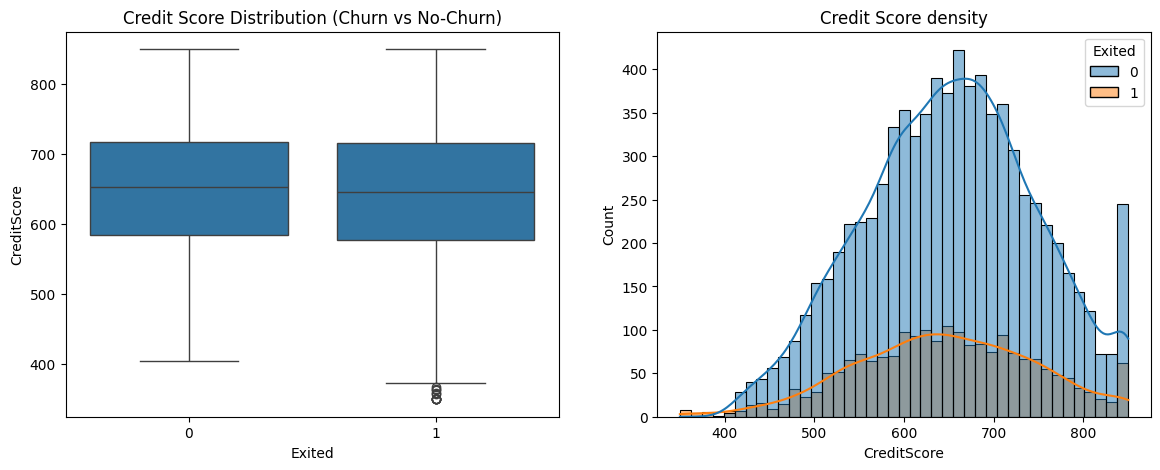

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Box plot for spread
sns.boxplot(x='Exited', y='CreditScore', data=df, ax=ax[0])
ax[0].set_title('Credit Score Distribution (Churn vs No-Churn)')

# Histogram for distribution
sns.histplot(x='CreditScore', hue='Exited', data=df, kde=True, ax=ax[1])
ax[1].set_title('Credit Score density')
plt.show()

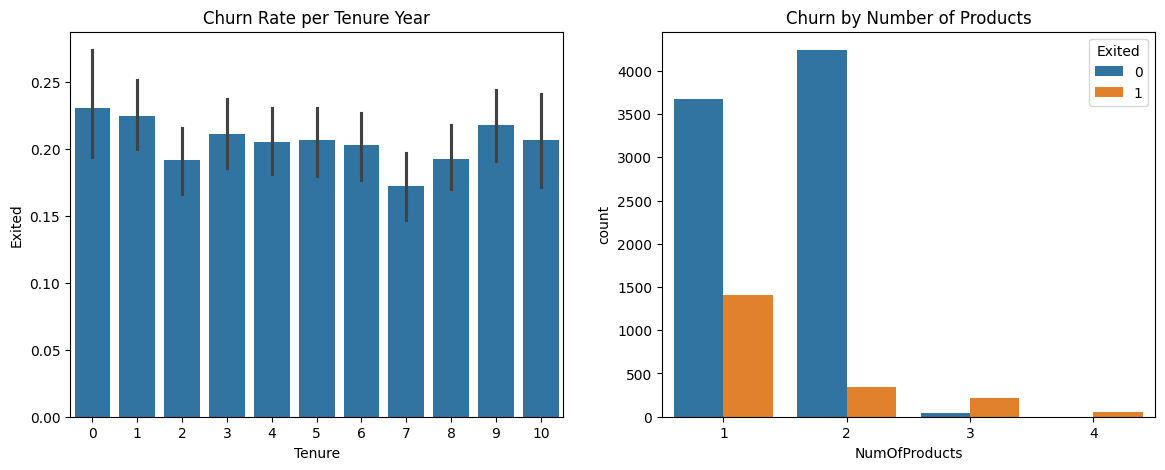

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart for Tenure
sns.barplot(x='Tenure', y='Exited', data=df, ax=ax[0])
ax[0].set_title('Churn Rate per Tenure Year')

# Count plot for Products
sns.countplot(x='NumOfProducts', hue='Exited', data=df, ax=ax[1])
ax[1].set_title('Churn by Number of Products')
plt.show()

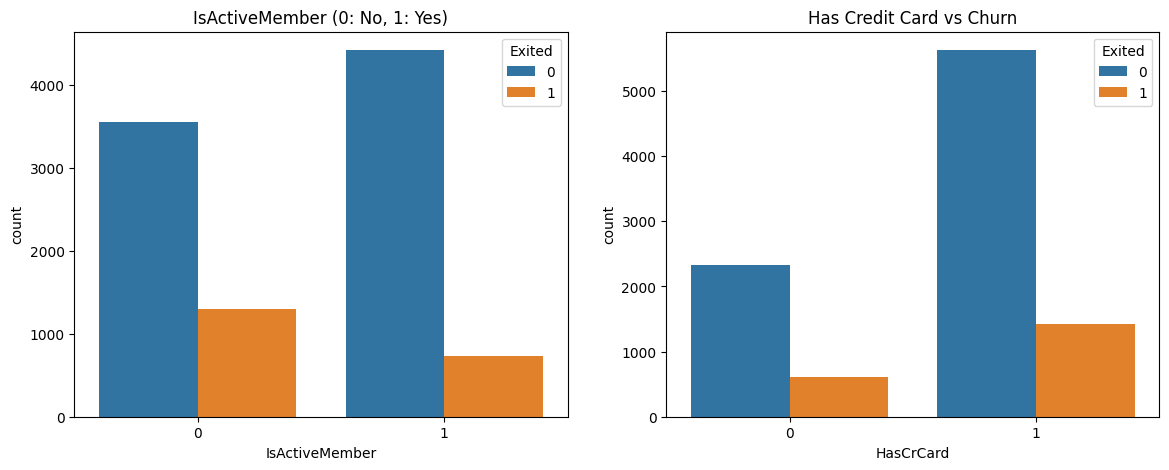

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, ax=ax[0])
ax[0].set_title('IsActiveMember (0: No, 1: Yes)')

sns.countplot(x='HasCrCard', hue='Exited', data=df, ax=ax[1])
ax[1].set_title('Has Credit Card vs Churn')
plt.show()

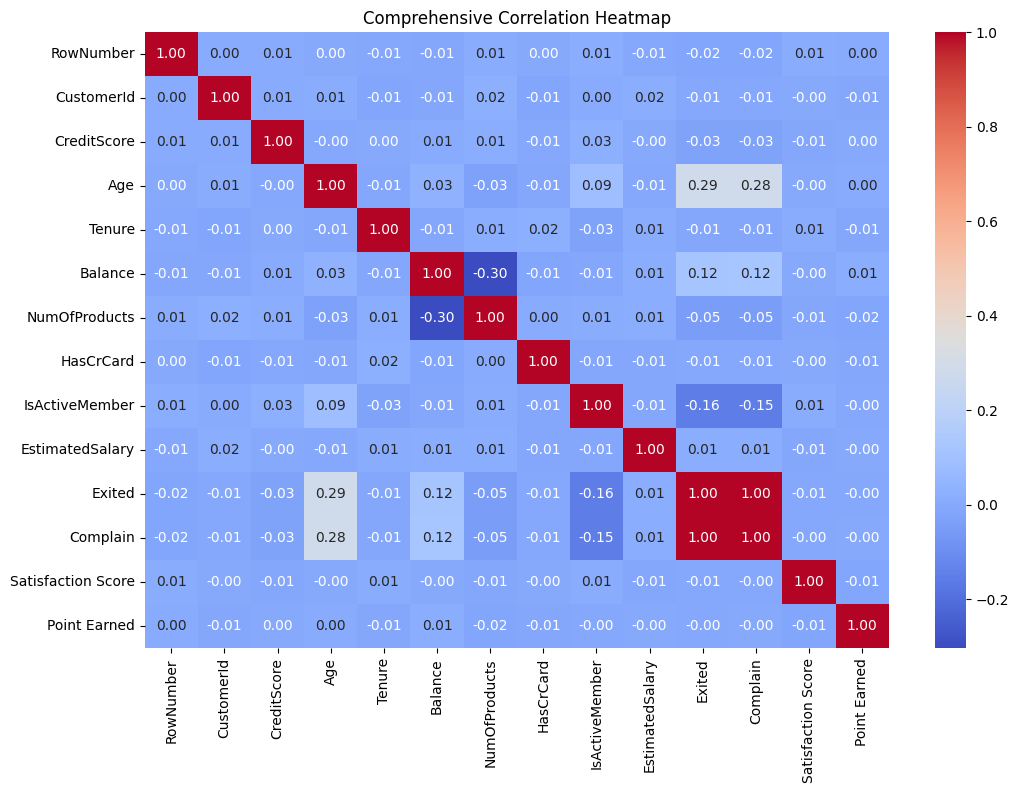

In [30]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
# Numeric columns ko nikal kar heatmap banate hain
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Comprehensive Correlation Heatmap')
plt.show()

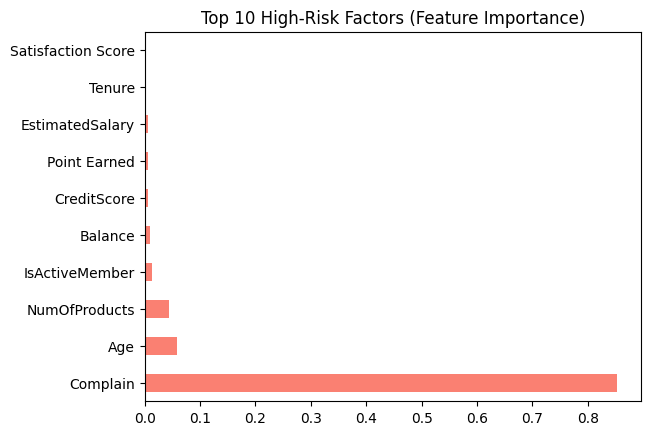

In [31]:
# Feature Importance using Random Forest (Model ka use karke importance dekhna)
from sklearn.ensemble import RandomForestClassifier

# Drop non-numeric and identifier columns before creating X
X = df.drop(['Exited', 'RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender', 'Card Type'], axis=1)
y = df['Exited']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature Importance Plot
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 High-Risk Factors (Feature Importance)')
plt.show()

In [32]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Complain']

In [33]:
df_clean = df.drop(columns=[c for c in columns_to_drop if c in df.columns], axis=1)

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report # Added this line

# 1. Cheating wale columns ko hatao
# 'Complain' ismein sabse bada culprit hai
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Complain']

# Drop karo (agar wo column exist karta hai)
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], axis=1)

# 2. Categorical variables ko numeric mein badlo (One-Hot Encoding)
df_clean = pd.get_dummies(df_clean, drop_first=True)

# 3. Split the data
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the model again
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
print("Real Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Real Accuracy: 0.8655
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



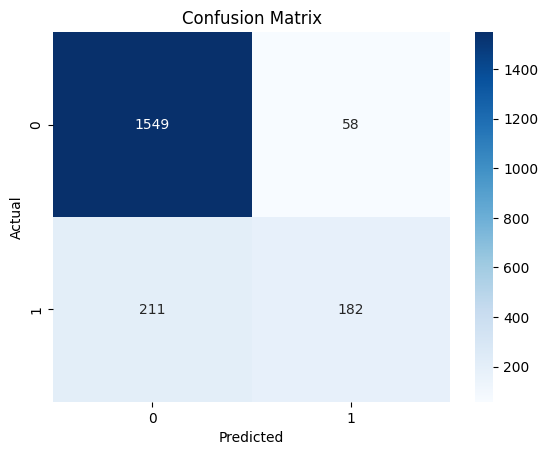

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

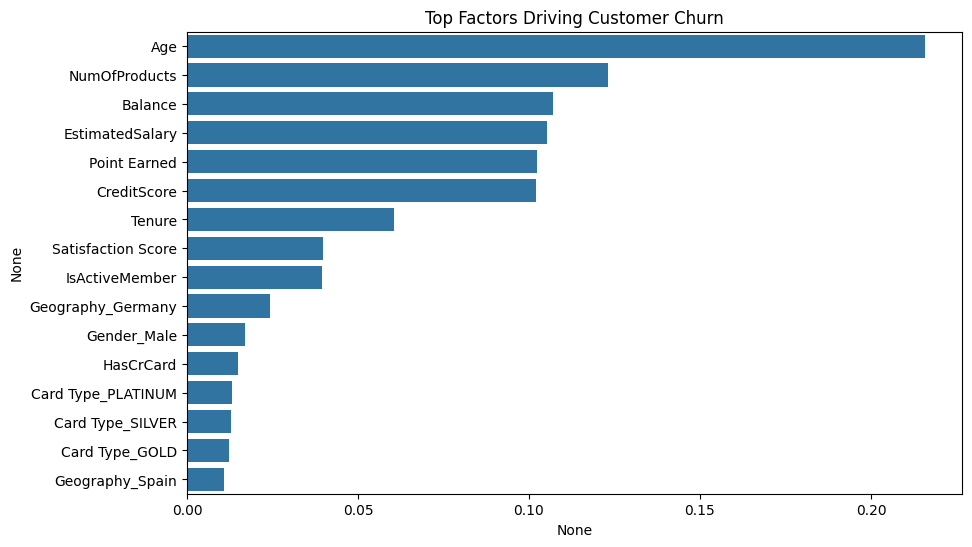

In [37]:
feature_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Top Factors Driving Customer Churn')
plt.show()

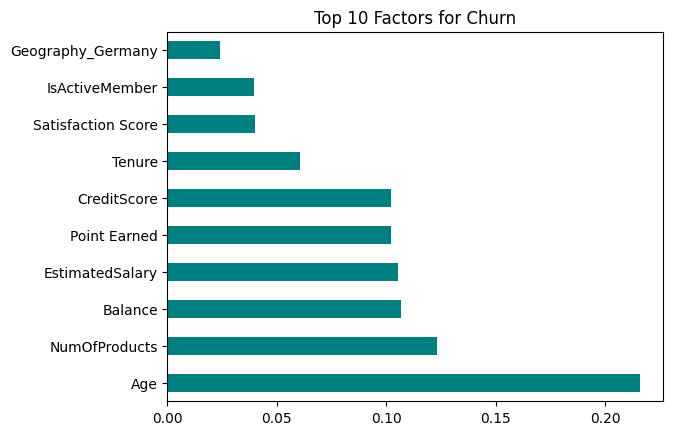

In [38]:
# Predictions
predictions = model.predict(X_test)
# Feature Importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors for Churn')
plt.show()

In [39]:
risk_scores = model.predict_proba(X_test)[:, 1] * 100
X_test_risk = X_test.copy()
X_test_risk['Churn_Risk_Score'] = risk_scores
print(X_test_risk[['Churn_Risk_Score']].head())

      Churn_Risk_Score
6252               7.0
4684               2.0
1731              16.0
4742              25.0
4521               7.0


In [40]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
X_test_risk['Segment'] = kmeans.fit_predict(X_test)
# Segment names: 0: Loyal, 1: At-Risk, 2: Premium, 3: New

In [41]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Model Params:", grid.best_params_)

Best Model Params: {'max_depth': 10, 'n_estimators': 100}


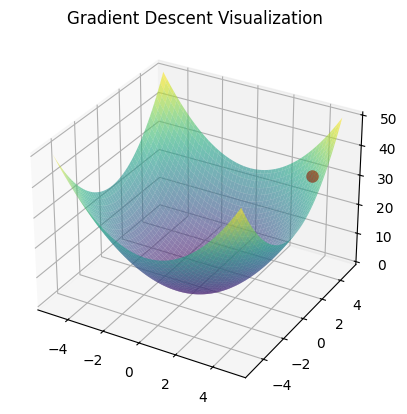

In [42]:

from matplotlib.animation import FuncAnimation

# 1. Surface Data (Loss Function)
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2  # Loss function (Paraboloid)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Gradient Descent Path
path_x, path_y = [4], [4]
learning_rate = 0.1
for _ in range(20):
    path_x.append(path_x[-1] - learning_rate * (2 * path_x[-1]))
    path_y.append(path_y[-1] - learning_rate * (2 * path_y[-1]))

point, = ax.plot([], [], [], 'ro', markersize=8)

def update(frame):
    point.set_data([path_x[frame]], [path_y[frame]])
    point.set_3d_properties([path_x[frame]**2 + path_y[frame]**2])
    return point,

ani = FuncAnimation(fig, update, frames=len(path_x), interval=500, blit=True)
plt.title("Gradient Descent Visualization")
plt.show()

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Load the DataFrame 'df' explicitly to ensure it's defined
df = pd.read_csv('/Customer-Churn-Records - Copy.csv')

# Re-creating df_clean and splitting data as done in cell STdfytsTD6zt
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], axis=1)
df_clean = pd.get_dummies(df_clean, drop_first=True)
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=200))
])
final_pipeline.fit(X_train, y_train)
# Ye pipeline ab kahin bhi deploy ho sakti hai!

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(n_estimators=200))])

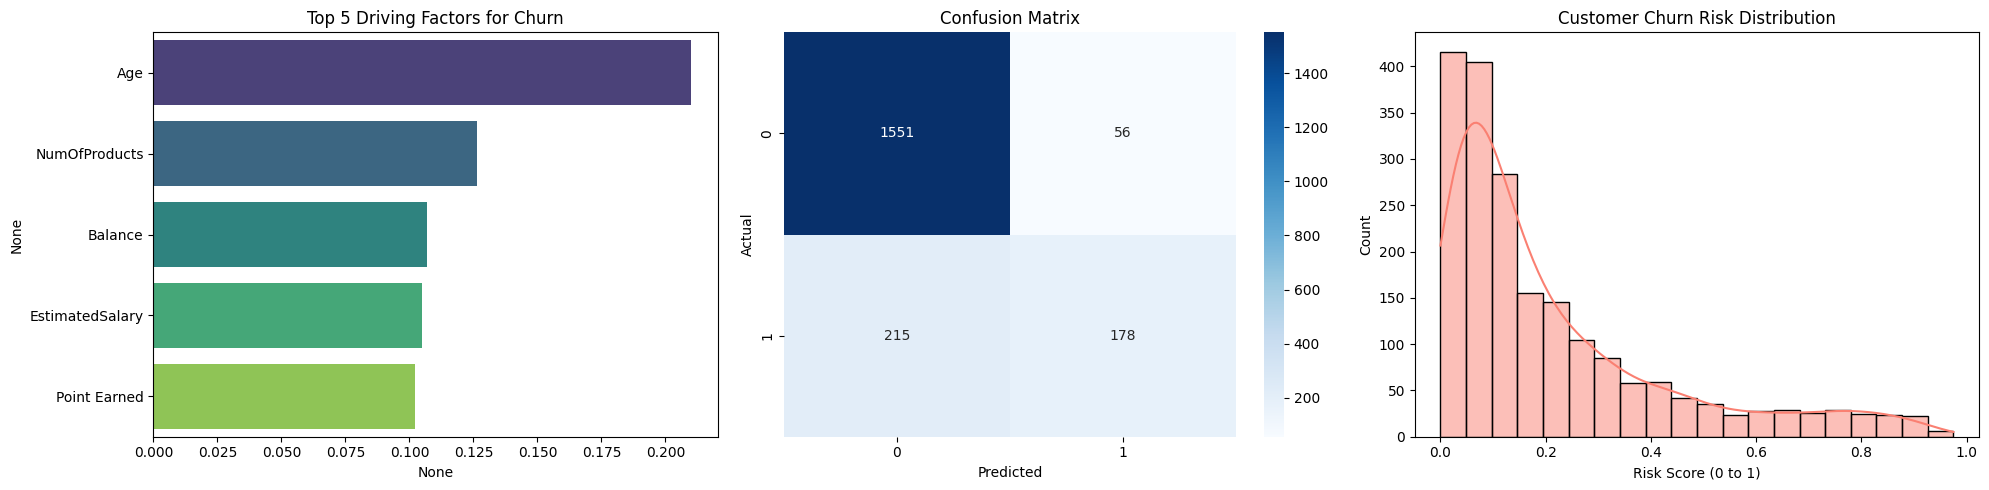

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Access the trained model from the pipeline
model = final_pipeline.named_steps['model']

# Generate predictions and probabilities using the fitted pipeline
y_pred = final_pipeline.predict(X_test)
y_probs = final_pipeline.predict_proba(X_test)[:, 1]

# Figure setup
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Feature Importance Plot
feat_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
# Addressing the FutureWarning: Assign the y variable to hue and set legend=False
sns.barplot(x=feat_importances.head(5), y=feat_importances.head(5).index, ax=axes[0], palette='viridis', hue=feat_importances.head(5).index, legend=False)
axes[0].set_title('Top 5 Driving Factors for Churn')

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. Risk Score Distribution (Probability)
sns.histplot(y_probs, bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Customer Churn Risk Distribution')
axes[2].set_xlabel('Risk Score (0 to 1)')

plt.tight_layout()
plt.show()

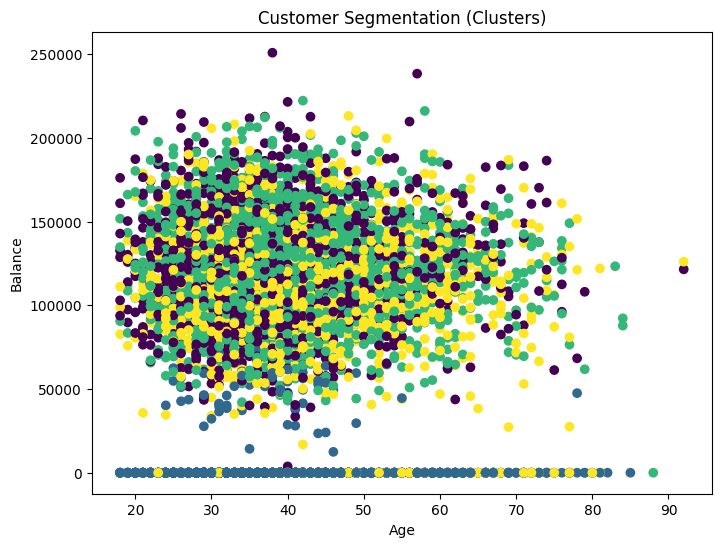

In [45]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Feature selection for clustering (sirf numerical columns lo)
# hum 'Balance', 'EstimatedSalary', 'Age', 'Tenure' use kar sakte hain
data_for_clustering = X[['Balance', 'EstimatedSalary', 'Age', 'Tenure']]

# 2. Scaling (ye bahut zaruri hai)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_for_clustering)

# 3. K-Means (4 groups/segments banane ke liye)
kmeans = KMeans(n_clusters=4, random_state=42)
data_for_clustering = data_for_clustering.copy()
data_for_clustering['Segment'] = kmeans.fit_predict(X_scaled)

# 4. Visualization (Clusters dekhne ke liye)
plt.figure(figsize=(8,6))
plt.scatter(data_for_clustering['Age'], data_for_clustering['Balance'], c=data_for_clustering['Segment'], cmap='viridis')
plt.title('Customer Segmentation (Clusters)')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

In [47]:
import pickle

# 1. Model ko save karo
with open('churn_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# 2. Agar aapne StandardScaler use kiya hai, toh use bhi save karo
# (Deployment mein input data ko scale karne ke liye ye bahut zaruri hai)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model and Scaler saved")

Model and Scaler saved
